# Classical and Quantum Model Comparisons

This notebook compares the archived global test-set results for the bathymetry regression models. It creates separate bar charts for MAE, RMSE, and R-squared, and compares classical and quantum model groups.

**Important:** confusion matrices and ROC-AUC curves are classification diagnostics. The primary task here is continuous-depth regression, so MAE, RMSE, and R-squared are the valid primary metrics. An optional depth-bin classification section is included only as an auxiliary diagnostic when actual and predicted values are available.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

## Archived Global Test Metrics

The values below are the results recorded in the existing model notebooks. This notebook does not retrain any classical or quantum model.

In [3]:
metrics = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "MLP",
        "SVR",
        "XGBoost",
        "Quantum VQR Method 1",
        "Quantum VQR Method 2"
    ],
    "MAE": [5.3373, 5.0608, 4.9935, 4.7868, 4.9535, 12.848148470349038, 7.65177],
    "RMSE": [6.6804, 6.6561, 6.3775, 6.6097, 6.4577, 15.553029571846455, 8.71635],
    "R2": [0.4334, 0.4375, 0.4836, 0.4453, 0.4706, -2.0710953875823437, 0.03543],
    "Family": [
        "Classical", "Classical", "Classical", "Classical", "Classical",
        "Quantum", "Quantum"
    ]
})

metrics

,Model,MAE,RMSE,R2,Family
0,Linear Regression,5.337300,6.68040,0.433400,Classical
1,Random Forest,5.060800,6.65610,0.437500,Classical
2,MLP,4.993500,6.37750,0.483600,Classical
3,SVR,4.786800,6.60970,0.445300,Classical
4,XGBoost,4.953500,6.45770,0.470600,Classical
5,Quantum VQR Method 1,12.848148,15.55303,-2.071095,Quantum
6,Quantum VQR Method 2,7.651770,8.71635,0.035430,Quantum


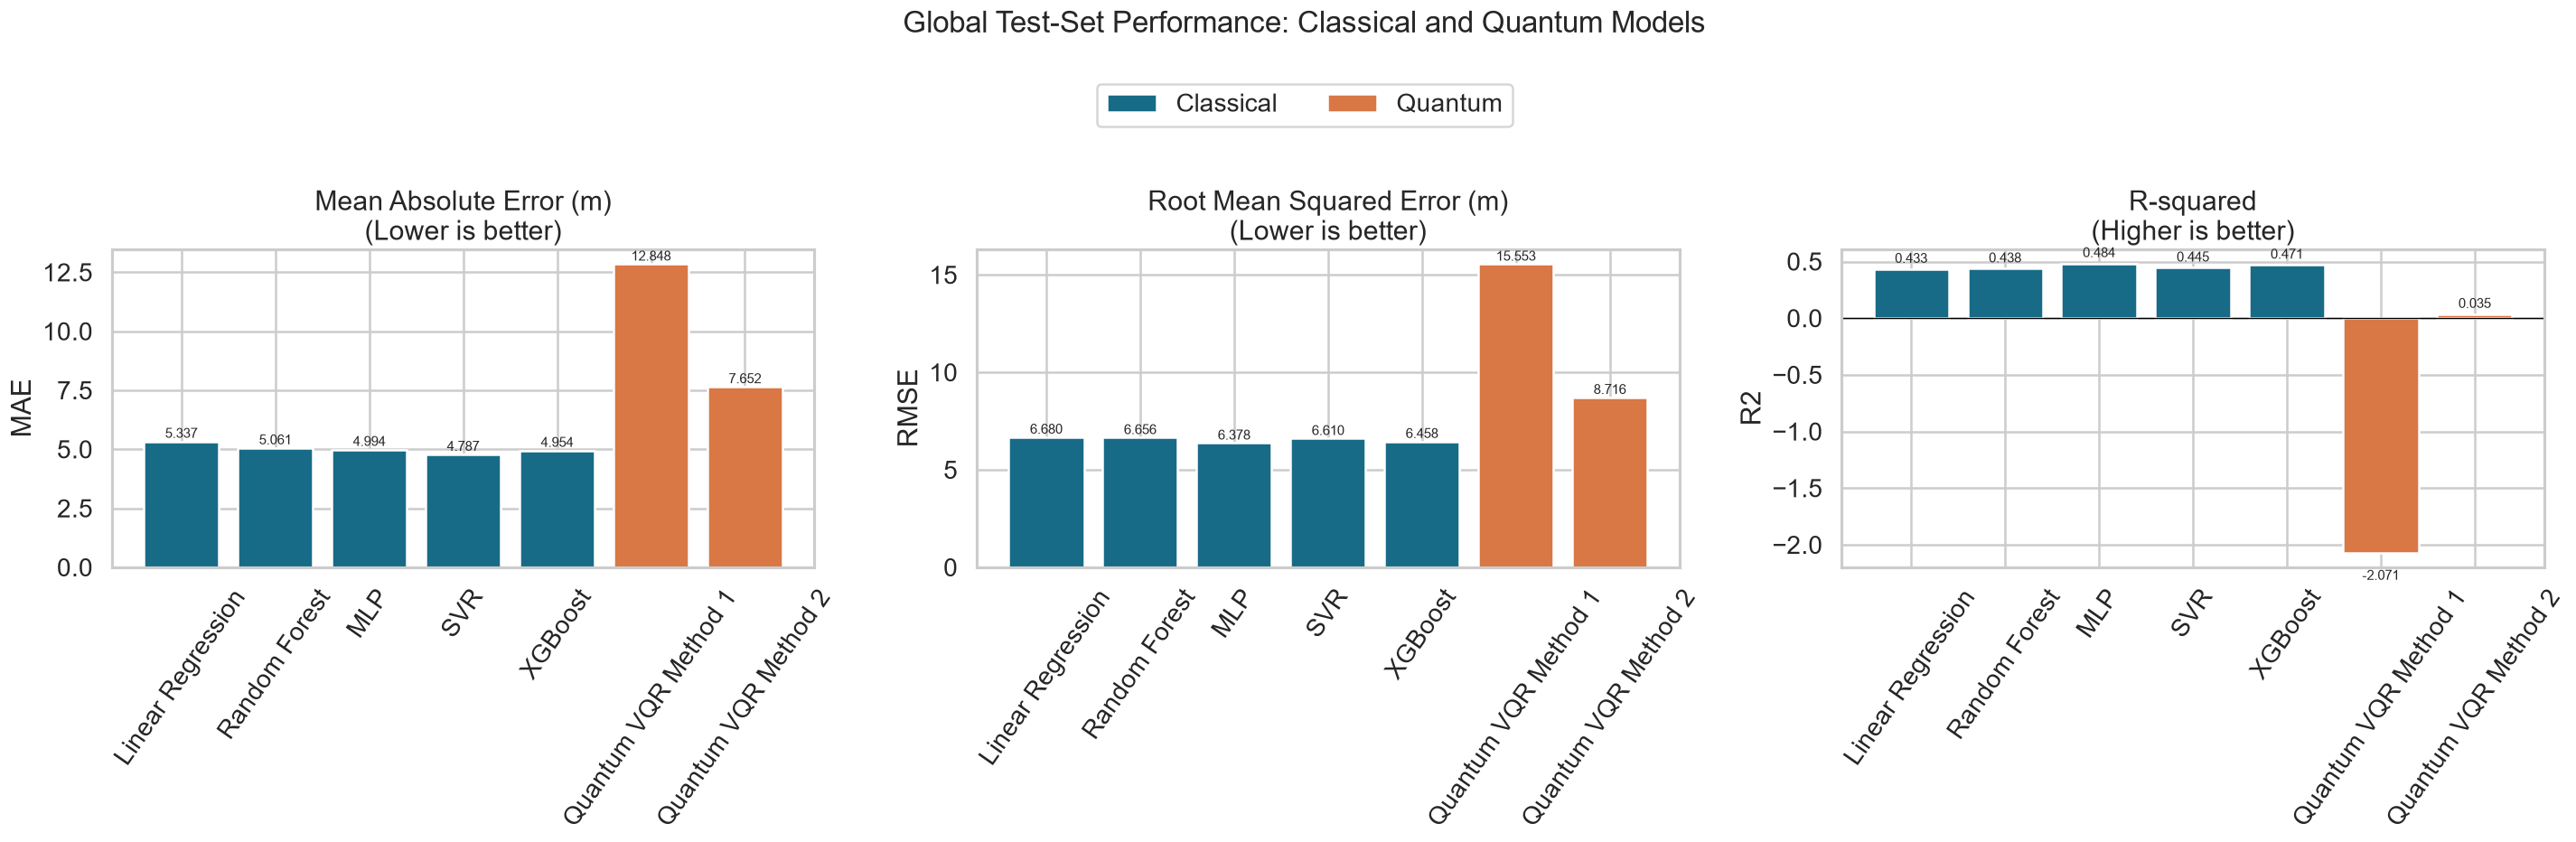

In [4]:
palette = {"Classical": "#176B87", "Quantum": "#D97745"}
colors = metrics["Family"].map(palette)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
metric_specs = [
    ("MAE", "Mean Absolute Error (m)", "Lower is better"),
    ("RMSE", "Root Mean Squared Error (m)", "Lower is better"),
    ("R2", "R-squared", "Higher is better")
]

for ax, (column, title, subtitle) in zip(axes, metric_specs):
    bars = ax.bar(metrics["Model"], metrics[column], color=colors)
    ax.set_title(f"{title}\n({subtitle})")
    ax.set_ylabel(column)
    ax.tick_params(axis="x", rotation=55)
    ax.axhline(0, color="black", linewidth=0.8)
    for bar, value in zip(bars, metrics[column]):
        offset = 0.03 if value >= 0 else -0.15
        ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f"{value:.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color, label=family) for family, color in palette.items()]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Global Test-Set Performance: Classical and Quantum Models", y=1.12, fontsize=20)
plt.tight_layout()
plt.show()

## Classical Versus Quantum Group Comparison

The group averages summarize the archived results. They should be interpreted carefully because the quantum group contains only two methods and one quantum method has a negative R-squared.

In [5]:
group_means = metrics.groupby("Family")[["MAE", "RMSE", "R2"]].mean().reindex(["Classical", "Quantum"])
group_means

,MAE,RMSE,R2
Family,,,
Classical,5.026380,6.55628,0.454080
Quantum,10.249959,12.13469,-1.017833


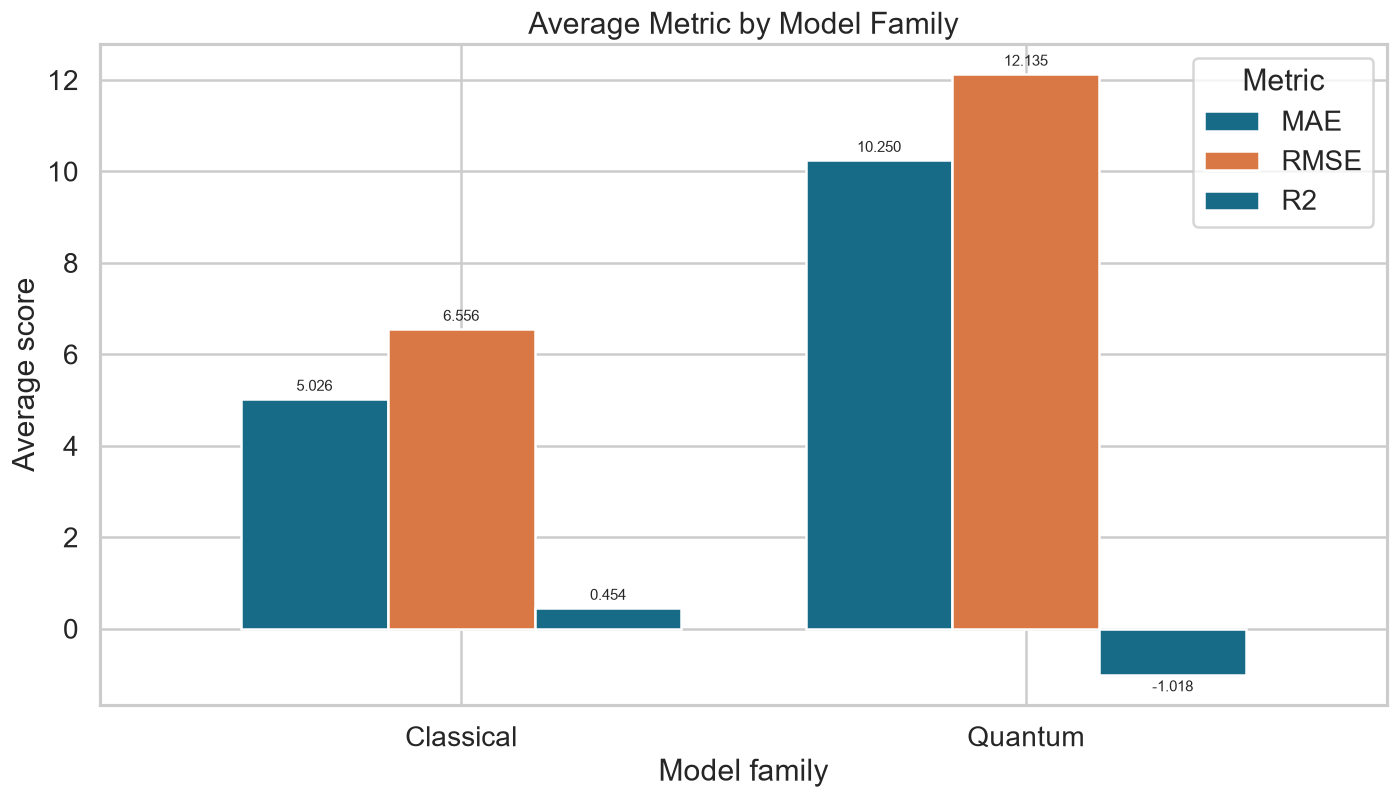

In [6]:
ax = group_means.plot(kind="bar", figsize=(12, 7), color=["#176B87", "#D97745"], width=0.78)
ax.set_title("Average Metric by Model Family")
ax.set_xlabel("Model family")
ax.set_ylabel("Average score")
ax.set_xticklabels(group_means.index, rotation=0)
ax.legend(title="Metric")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## Training and Validation Curves

Training and validation curves are useful for diagnosing overfitting and underfitting. The archived project notebooks do not contain complete epoch-by-epoch validation histories for the classical models. Quantum Method 2 records training-loss checkpoints, but it does not record a validation-loss history. The following plot therefore shows the available quantum training checkpoints and a clearly marked missing-data panel for the classical validation curves.

To generate complete curves in a future experiment, save each model's training and validation loss at every epoch or iteration using the same train/validation split.

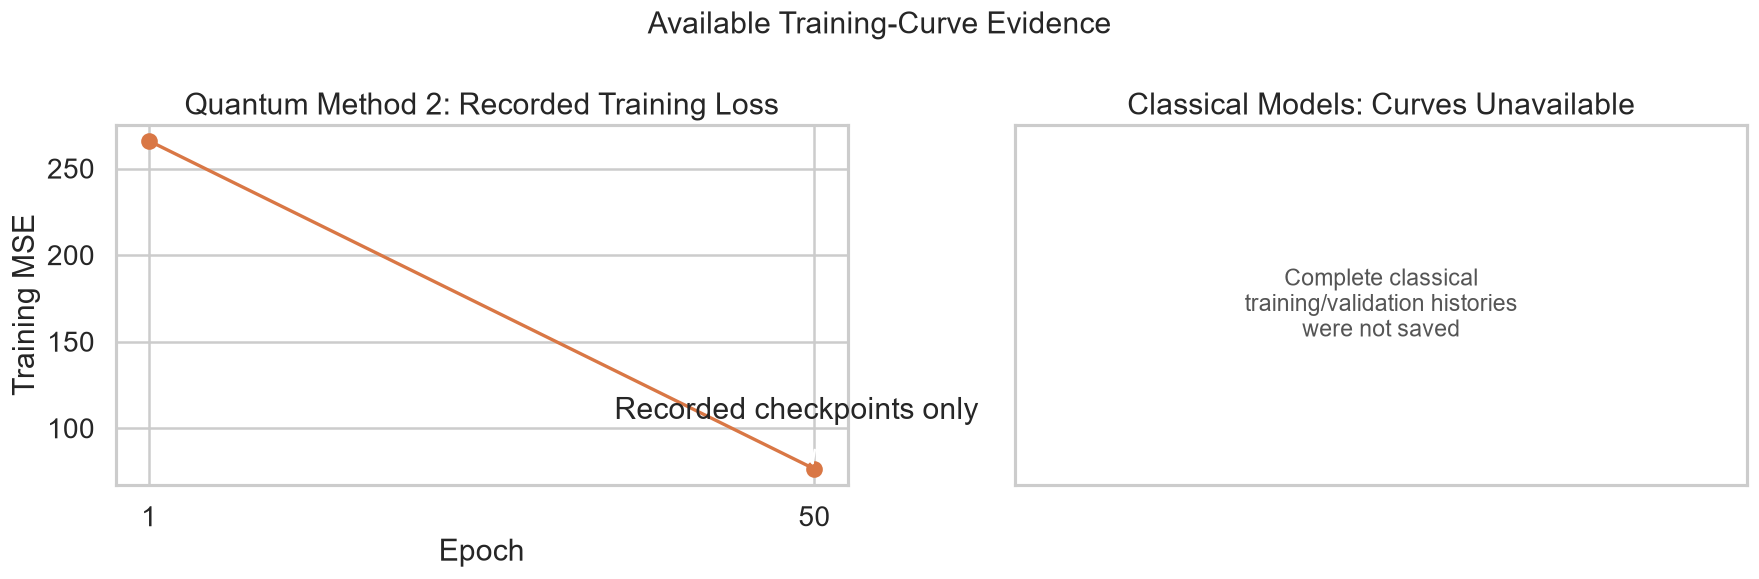

In [8]:
# Archived learning-curve evidence only. No model training is performed here.
quantum2_epochs = np.array([1, 50])
quantum2_train_mse = np.array([265.97241, 76.50291])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(quantum2_epochs, quantum2_train_mse, marker="o", linewidth=2, color="#D97745")
axes[0].set_title("Quantum Method 2: Recorded Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training MSE")
axes[0].set_xticks(quantum2_epochs)
axes[0].annotate("Recorded checkpoints only", (quantum2_epochs[-1], quantum2_train_mse[-1]), xytext=(-120, 30), textcoords="offset points", arrowprops={"arrowstyle": "->"})

axes[1].text(0.5, 0.5, "Complete classical\ntraining/validation histories\nwere not saved", ha="center", va="center", fontsize=14, color="#555555")
axes[1].set_title("Classical Models: Curves Unavailable")
axes[1].set_xticks([])
axes[1].set_yticks([])

fig.suptitle("Available Training-Curve Evidence", fontsize=18)
plt.tight_layout()
plt.show()

## Runtime, Resource Footprint, and Deployment Feasibility

The notebooks report model configurations and prediction metrics, but they do not record wall-clock training time, inference time, peak memory, CPU usage, or model file size. Those values are therefore shown as unavailable rather than estimated. The qualitative ratings below are based on the algorithms and configurations used in the project and should be replaced with measured values in a controlled benchmark.

- **Runtime:** measured values require timing the same training and prediction workflow for every model.
- **Resource footprint:** should be measured using peak memory and serialized model size.
- **Deployment feasibility:** reflects dependency complexity, CPU suitability, and operational simplicity.

In [9]:
tradeoffs = pd.DataFrame({
    "Model": metrics["Model"],
    "Family": metrics["Family"],
    "MAE (m)": metrics["MAE"],
    "RMSE (m)": metrics["RMSE"],
    "R2": metrics["R2"],
    "Training runtime": ["Not recorded"] * 7,
    "Inference runtime": ["Not recorded"] * 7,
    "Resource footprint": [
        "Low", "Medium", "Medium", "Medium", "Medium", "High", "High"
    ],
    "Deployment feasibility": [
        "Very high", "High", "Medium", "Medium", "Medium", "Low", "Low"
    ],
    "Deployment rationale": [
        "Small CPU model; minimal dependencies",
        "CPU-friendly ensemble; moderate model size",
        "Requires scikit-learn and feature scaler",
        "Requires scikit-learn and feature scaler",
        "Requires XGBoost runtime",
        "Requires Qiskit and quantum backend/simulator",
        "Requires PennyLane and quantum backend/simulator"
    ]
})

tradeoffs

,Model,Family,MAE (m),RMSE (m),R2,Training runtime,Inference runtime,Resource footprint,Deployment feasibility,Deployment rationale
0,Linear Regression,Classical,5.337300,6.68040,0.433400,Not recorded,Not recorded,Low,Very high,Small CPU model; minimal dependencies
1,Random Forest,Classical,5.060800,6.65610,0.437500,Not recorded,Not recorded,Medium,High,CPU-friendly ensemble; moderate model size
2,MLP,Classical,4.993500,6.37750,0.483600,Not recorded,Not recorded,Medium,Medium,Requires scikit-learn and feature scaler
3,SVR,Classical,4.786800,6.60970,0.445300,Not recorded,Not recorded,Medium,Medium,Requires scikit-learn and feature scaler
4,XGBoost,Classical,4.953500,6.45770,0.470600,Not recorded,Not recorded,Medium,Medium,Requires XGBoost runtime
5,Quantum VQR Method 1,Quantum,12.848148,15.55303,-2.071095,Not recorded,Not recorded,High,Low,Requires Qiskit and quantum backend/simulator
6,Quantum VQR Method 2,Quantum,7.651770,8.71635,0.035430,Not recorded,Not recorded,High,Low,Requires PennyLane and quantum backend/simulator


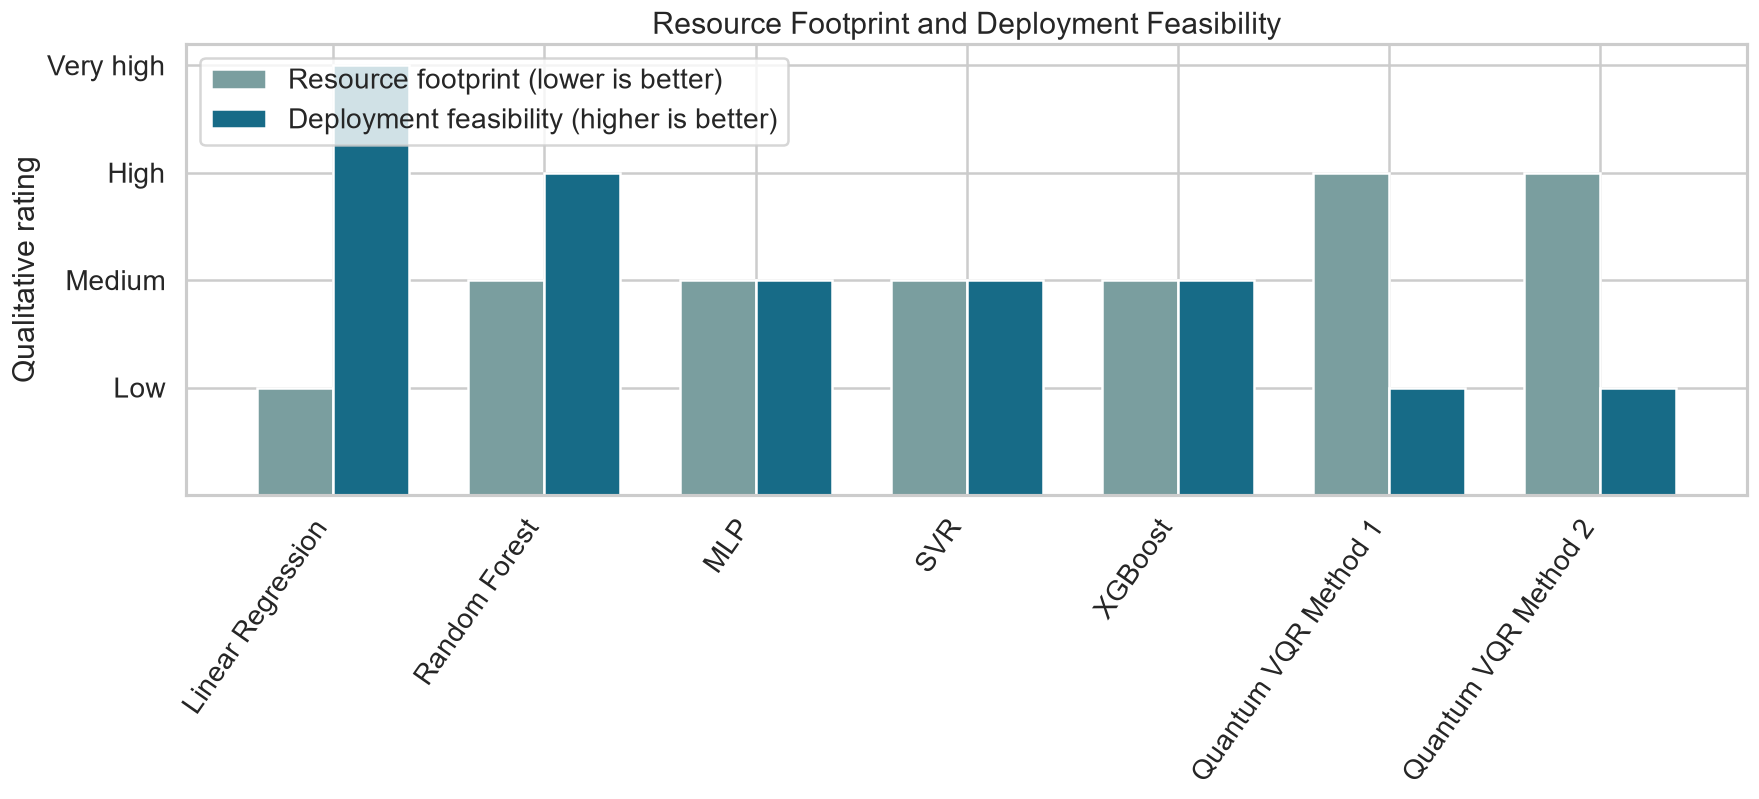

In [10]:
footprint_score = {"Low": 1, "Medium": 2, "High": 3}
deployment_score = {"Very high": 4, "High": 3, "Medium": 2, "Low": 1}

tradeoff_plot = tradeoffs[["Model", "Resource footprint", "Deployment feasibility"]].copy()
tradeoff_plot["Resource score"] = tradeoff_plot["Resource footprint"].map(footprint_score)
tradeoff_plot["Deployment score"] = tradeoff_plot["Deployment feasibility"].map(deployment_score)

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(tradeoff_plot))
width = 0.36
ax.bar(x - width / 2, tradeoff_plot["Resource score"], width, label="Resource footprint (lower is better)", color="#7A9E9F")
ax.bar(x + width / 2, tradeoff_plot["Deployment score"], width, label="Deployment feasibility (higher is better)", color="#176B87")
ax.set_xticks(x)
ax.set_xticklabels(tradeoff_plot["Model"], rotation=55, ha="right")
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Low", "Medium", "High", "Very high"])
ax.set_ylabel("Qualitative rating")
ax.set_title("Resource Footprint and Deployment Feasibility")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Optional Auxiliary Depth-Bin Diagnostics

Confusion matrices and ROC-AUC curves require discrete classes and therefore are not direct regression evaluations. The following cell is disabled by default. To use it, provide the actual and predicted continuous test depths from a model, then set `RUN_AUXILIARY_CLASSIFICATION = True`.

The bins below are shallow-depth categories: 0-10 m, 10-20 m, and 20-30 m. The resulting confusion matrix and ROC-AUC describe agreement between these derived categories, not continuous bathymetric accuracy.

In [7]:
RUN_AUXILIARY_CLASSIFICATION = False

# Replace these placeholders with matching test-set arrays before enabling the cell.
y_actual = None
y_predicted = None
model_name = "Example model"

if RUN_AUXILIARY_CLASSIFICATION:
    if y_actual is None or y_predicted is None:
        raise ValueError("Provide y_actual and y_predicted arrays before enabling this diagnostic.")
    if len(y_actual) != len(y_predicted):
        raise ValueError("y_actual and y_predicted must have the same length.")

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
    from sklearn.preprocessing import label_binarize

    bin_edges = [0, 10, 20, 30.000001]
    bin_labels = ["0-10 m", "10-20 m", "20-30 m"]
    actual_bins = pd.cut(y_actual, bins=bin_edges, labels=bin_labels, include_lowest=True)
    predicted_bins = pd.cut(np.clip(y_predicted, 0, 30), bins=bin_edges, labels=bin_labels, include_lowest=True)

    cm = confusion_matrix(actual_bins, predicted_bins, labels=bin_labels)
    ConfusionMatrixDisplay(cm, display_labels=bin_labels).plot(cmap="Blues", values_format="d")
    plt.title(f"Auxiliary Depth-Bin Confusion Matrix: {model_name}")
    plt.tight_layout()
    plt.show()

    actual_numeric = pd.Categorical(actual_bins, categories=bin_labels).codes
    predicted_numeric = pd.Categorical(predicted_bins, categories=bin_labels).codes
    actual_one_hot = label_binarize(actual_numeric, classes=range(len(bin_labels)))
    predicted_scores = np.eye(len(bin_labels))[predicted_numeric]
    auc = roc_auc_score(actual_one_hot, predicted_scores, multi_class="ovr", average="macro")
    print(f"Auxiliary one-vs-rest macro ROC-AUC: {auc:.4f}")
    RocCurveDisplay.from_predictions(actual_one_hot.ravel(), predicted_scores.ravel())
    plt.title(f"Auxiliary ROC Curve for Depth Bins: {model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Auxiliary classification diagnostics are disabled. Use MAE, RMSE, and R-squared for the primary regression evaluation.")

Auxiliary classification diagnostics are disabled. Use MAE, RMSE, and R-squared for the primary regression evaluation.
